In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt

from src.analysis import run_two_way_sensitivity_analysis
from src.config import variable_names
from src.core import Variable
from src.models import OperatingIncomeModel, NetIncomeModel, MarketPriceModel
from src.variables import PriceToEarningsRatio
from src.visualization import generate_heatmap_from_df
from src.utils import plot_multiple_views

In [2]:
variables = {
    variable_names.REVENUE: Variable(min=80000.0, exp=100000.0, max=120000.0),
    variable_names.COGS: Variable(min=30000.0, exp=40000.0, max=50000.0),
    variable_names.PE_RATIO: PriceToEarningsRatio(min=5.0, exp=8.0, max=10.0)
}

pipeline = [OperatingIncomeModel(), NetIncomeModel(), MarketPriceModel()]

In [3]:
two_way_sensitivity_analysis_report = run_two_way_sensitivity_analysis(
    variables=variables,
    param_x_name=variable_names.REVENUE,
    param_y_name=variable_names.COGS,
    model_pipeline=pipeline,
    target_output_name=variable_names.MARKET_PRICE,
    x_steps=20,
    y_steps=20
)

In [4]:
# print(two_way_sensitivity_analysis_report)

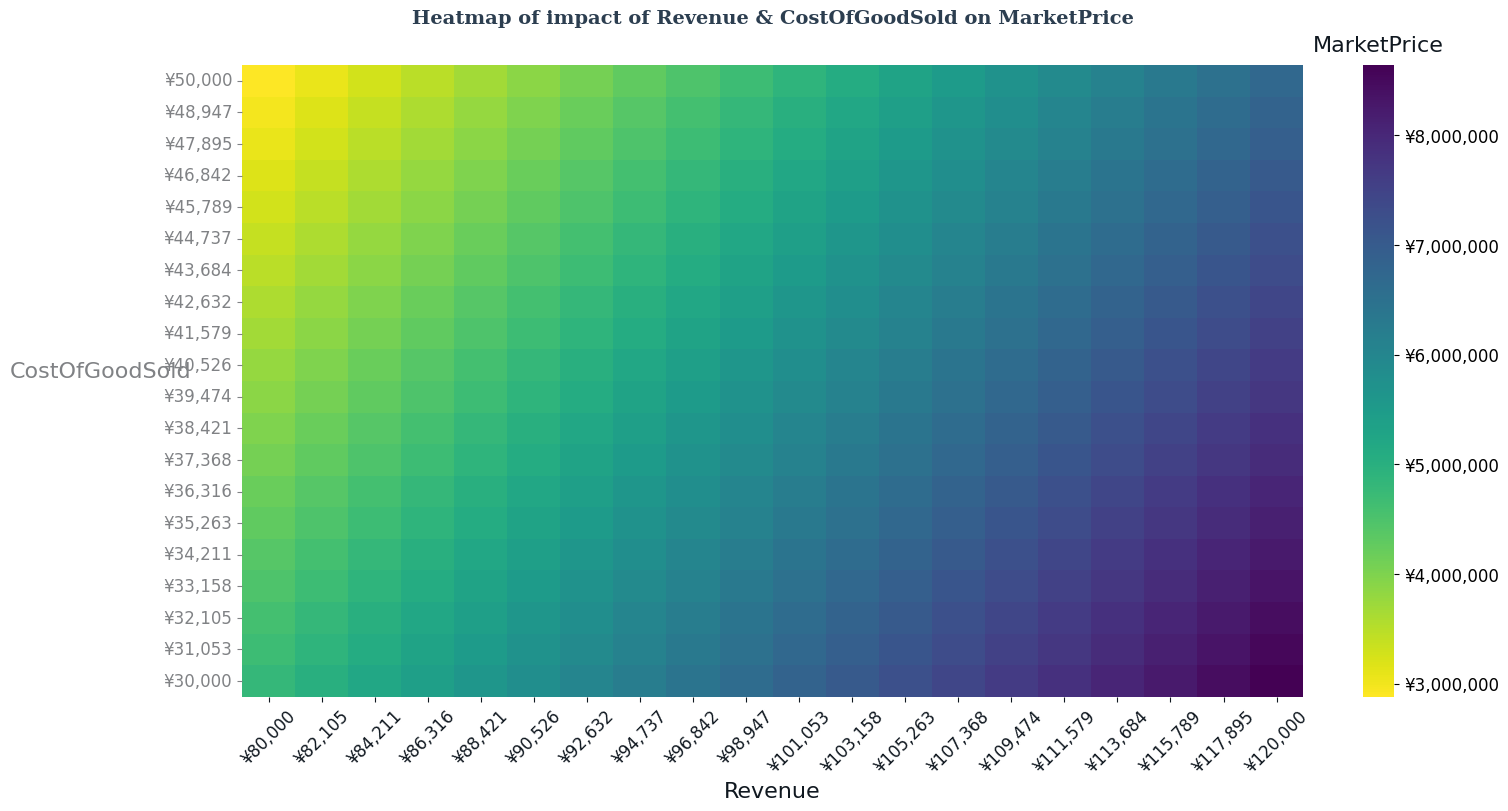

In [5]:
fig = generate_heatmap_from_df(two_way_sensitivity_analysis_report, variable_names.MARKET_PRICE)

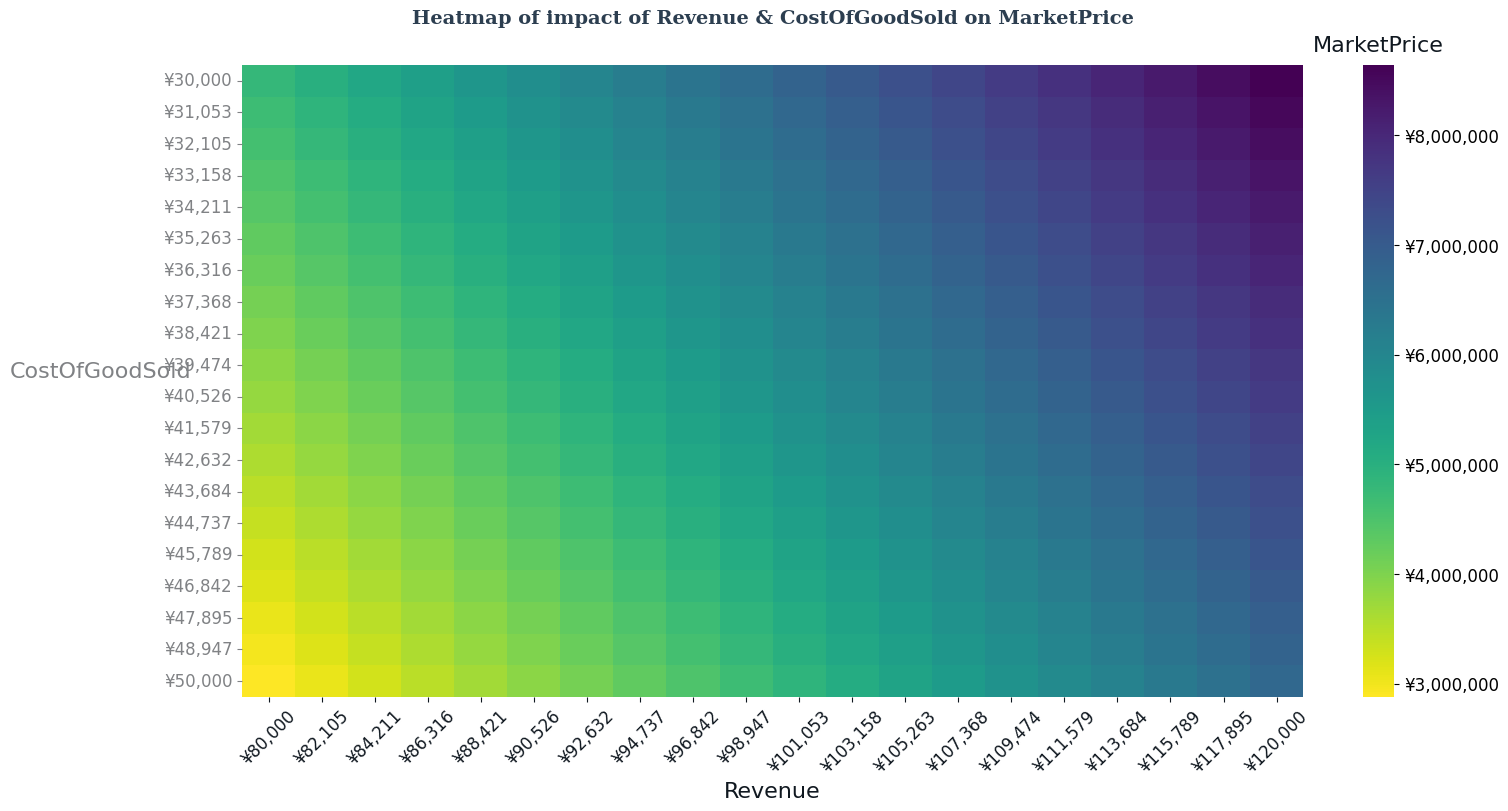

In [6]:
two_way_sensitivity_analysis_cost_decreasing_report = run_two_way_sensitivity_analysis(
    variables=variables,
    param_x_name=variable_names.REVENUE,
    param_y_name=variable_names.COGS,
    model_pipeline=pipeline,
    target_output_name=variable_names.MARKET_PRICE,
    reverse_y=False,
    x_steps=20,
    y_steps=20
)

fig = generate_heatmap_from_df(two_way_sensitivity_analysis_cost_decreasing_report, variable_names.MARKET_PRICE)

In [7]:
plt.close(fig)

In [8]:
plot_functions = [
    lambda ax: generate_heatmap_from_df(two_way_sensitivity_analysis_cost_decreasing_report, variable_names.MARKET_PRICE, ax=ax, title="Impact on MarketPrice"),
    lambda ax: generate_heatmap_from_df(two_way_sensitivity_analysis_cost_decreasing_report, variable_names.MARKET_PRICE, ax=ax),
]

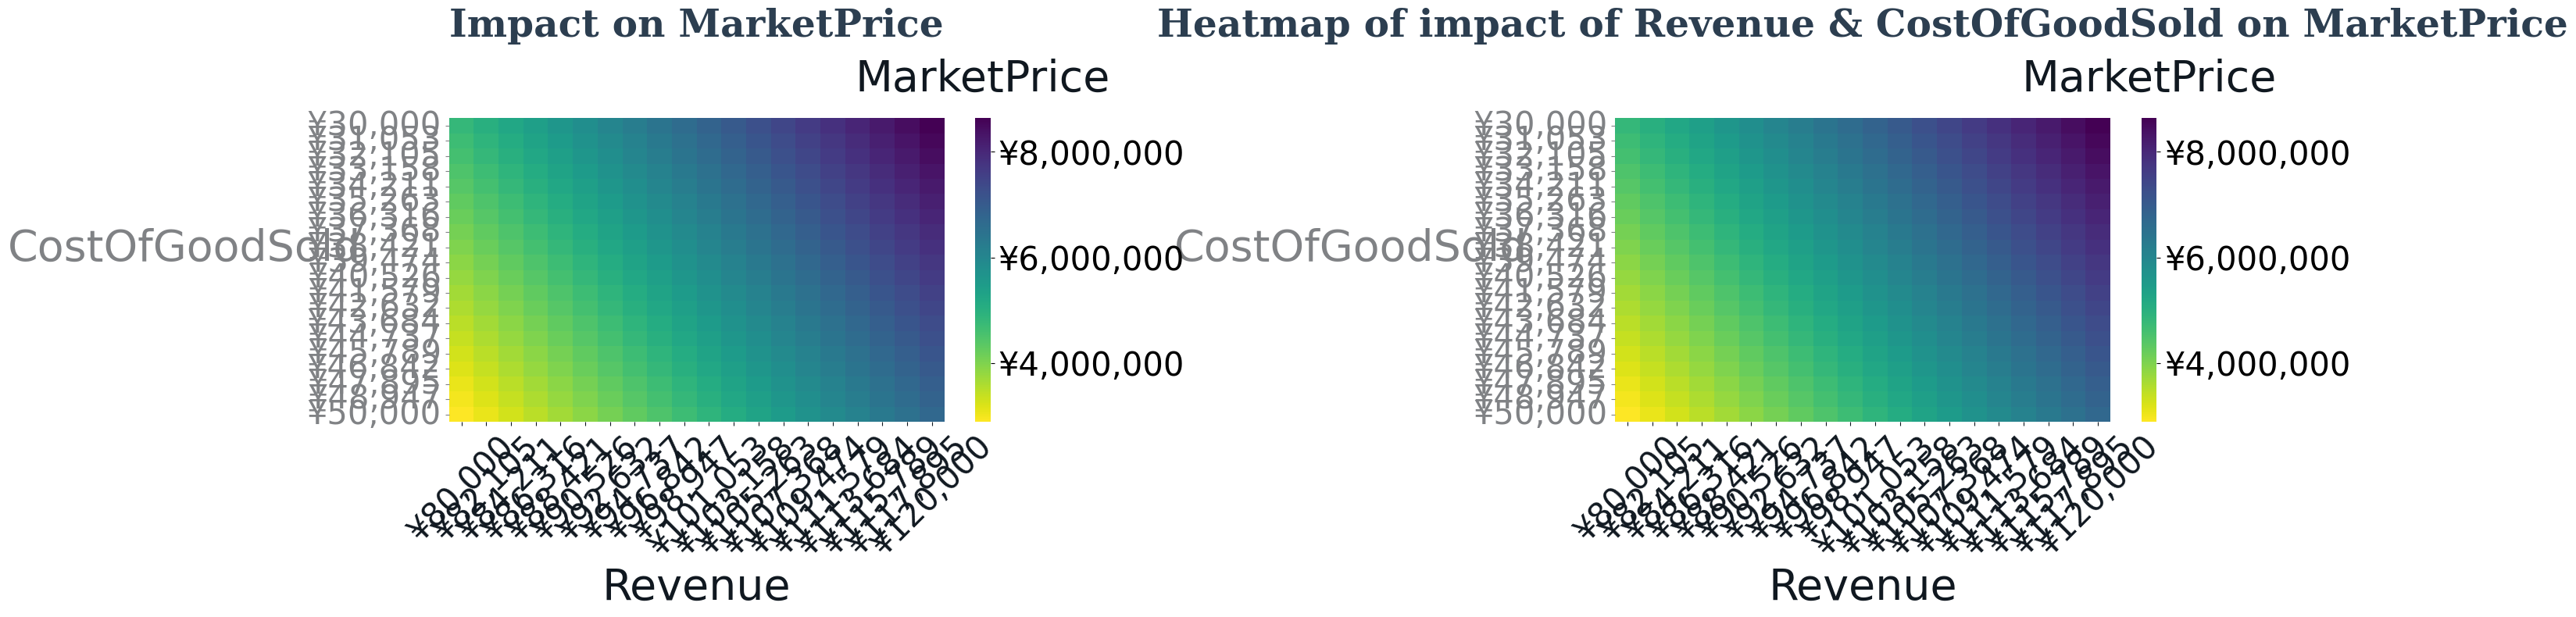

In [9]:
fig = plot_multiple_views(plot_functions)

In [10]:
plt.close(fig)